# Data Preprocessing Pipeline for PM2.5 Prediction Model

This notebook implements a comprehensive 7-phase preprocessing pipeline designed for machine learning model development:

**Phase 1:** Data Exploration & Profiling

**Phase 2:** Intelligent Missing Value Imputation

**Phase 3:** Feature Engineering (Temporal + Interaction Features)

**Phase 4:** Multi-Strategy Scaling (Group-Specific Approach)

**Phase 5:** Temporal Train/Val/Test Split (Prevents Data Leakage)

**Phase 6:** Correlation Analysis & Redundant Feature Removal

**Phase 7:** Quality Assurance & Overfitting Detection Setup

## Critical ML Principles Implemented:
- **Temporal Split:** Train/Val/Test split by date (not random) to respect causality
- **No Data Leakage:** Scalers and imputers fit ONLY on training data
- **Preserve Outliers:** Keep extreme values (important for air quality extremes)
- **Overfitting Detection:** Monitor train vs validation error gaps
- **TimeSeriesSplit:** For cross-validation during model training

## Setup: Import Libraries and Configure Paths

In [103]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer

# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

data_dir = base_dir / 'data'
output_dir = base_dir / 'preprocessed_data'
output_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

Base directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach
Data directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\data
Output directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\preprocessed_data


---
# PHASE 1: Data Exploration & Profiling

Load the merged dataset and explore its structure, missing values, and distributions.

In [71]:
# Load merged data
combined_file = data_dir / 'final_dataset_with_landuse.csv'
df = pd.read_csv(combined_file)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (83704, 47)

Column names and types:
date                             object
id                                int64
latitude                        float64
longitude                       float64
AOD                             float64
country                          object
location_name                    object
timezone                         object
last_updated_epoch                int64
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit       

,date,id,latitude,longitude,AOD,country,location_name,timezone,last_updated_epoch,temperature_celsius,...,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,building_density,road_density_km,industrial_presence,green_space_fraction
0,2024-05-16,0,-41.30,174.78,0.149667,New Zealand,Wellington,Pacific/Auckland,1715849100,13.0,...,07:24 AM,05:11 PM,01:57 PM,No moonset,Waxing Gibbous,55,18538,876.843984,17,3020
1,2024-05-16,4,-35.28,149.22,0.120500,Australia,Canberra,Australia/Sydney,1715849100,9.0,...,06:52 AM,05:07 PM,01:31 PM,No moonset,Waxing Gibbous,55,28,77.403319,0,1
2,2024-05-16,7,-34.59,-58.67,0.020000,Argentina,Buenos Aires,America/Argentina/Buenos_Aires,1715849100,8.0,...,07:43 AM,05:59 PM,02:36 PM,01:04 AM,Waxing Gibbous,55,86,326.449647,8,29
3,2024-05-16,7,-34.59,-58.67,0.020000,Argentina,Buenos Aires,America/Argentina/Buenos_Aires,1715868000,11.0,...,07:43 AM,05:59 PM,02:36 PM,01:04 AM,Waxing Gibbous,55,86,326.449647,8,29
4,2024-05-16,9,-33.45,-70.67,0.178500,Chile,Santiago,America/Santiago,1715849100,1.0,...,07:28 AM,05:50 PM,02:23 PM,12:56 AM,Waxing Gibbous,55,6653,600.266048,26,5153


In [72]:

def display_feature_statistics(df):
    print("=" * 60)
    print(f"DATASET STATISTICS SUMMARY (Total Rows: {len(df)})")
    print("=" * 60)
    
    # Separate numerical columns from categorical/temporal columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    print("\n--- NUMERICAL FEATURES ---")
    for col in num_cols:
        
        # Calculate statistics
        min_val = df[col].min()
        max_val = df[col].max()
        mean_val = df[col].mean()
        median_val = df[col].median()
        std_val = df[col].std()
        
        print(f"\n🔹 {col}:")
        print(f"   Range:   [{min_val:.4f}, {max_val:.4f}]")
        print(f"   Mean:    {mean_val:.4f} | Median: {median_val:.4f} | Std: {std_val:.4f}")

                
    print("\n" + "=" * 60)

display_feature_statistics(df)

DATASET STATISTICS SUMMARY (Total Rows: 83704)

--- NUMERICAL FEATURES ---

🔹 id:
   Range:   [0.0000, 438.0000]
   Mean:    222.2941 | Median: 236.0000 | Std: 122.3828

🔹 latitude:
   Range:   [-41.3000, 64.1500]
   Mean:    19.1228 | Median: 18.5400 | Std: 24.5187

🔹 longitude:
   Range:   [-175.2000, 179.2200]
   Mean:    20.7929 | Median: 24.7000 | Std: 63.8061

🔹 AOD:
   Range:   [0.0000, 6.8750]
   Mean:    0.2077 | Median: 0.1700 | Std: 0.1866

🔹 last_updated_epoch:
   Range:   [1715849100.0000, 1777702500.0000]
   Mean:    1746440075.8614 | Median: 1746693900.0000 | Std: 17780715.2816

🔹 temperature_celsius:
   Range:   [-19.6000, 49.2000]
   Mean:    22.4790 | Median: 24.1000 | Std: 8.8732

🔹 temperature_fahrenheit:
   Range:   [-3.3000, 120.6000]
   Mean:    72.4640 | Median: 75.5000 | Std: 15.9718

🔹 wind_mph:
   Range:   [2.2000, 1841.2000]
   Mean:    8.1365 | Median: 6.9000 | Std: 8.1673

🔹 wind_kph:
   Range:   [3.6000, 2963.2000]
   Mean:    13.0980 | Median: 11.2000 | 

Missing Values Summary:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percent]
Index: []


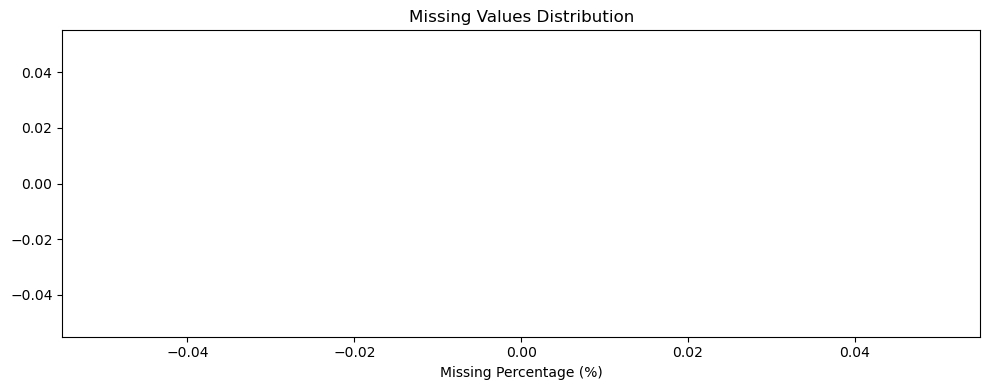


Total rows: 83704
Rows with complete data: 83704 (100.0%)


In [73]:
# Missing values overview
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_data = missing_df[missing_df['Missing_Count'] > 0]
ax.barh(missing_data['Column'], missing_data['Missing_Percent'], color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values Distribution')
plt.tight_layout()
plt.show()

print(f"\nTotal rows: {len(df)}")
print(f"Rows with complete data: {len(df.dropna())} ({len(df.dropna())/len(df)*100:.1f}%)")

In [74]:
# Identify feature categories
print("Feature Categorization:")
print("\n1. TEMPORAL FEATURES:")
temporal_cols = ['date']
for col in temporal_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n2. GEOGRAPHIC FEATURES:")
geo_cols = ['latitude', 'longitude', 'id', 'country', 'location_name', 'timezone']
for col in geo_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n3. METEOROLOGICAL FEATURES:")
met_cols = ['temperature_celsius', 'pressure_mb', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'precip_mm']
for col in met_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)")

print("\n4. WIND FEATURES:")
wind_cols = ['wind_kph', 'wind_degree', 'wind_direction', 'gust_kph']
for col in wind_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)")

print("\n5. ATMOSPHERIC POLLUTION & AIR QUALITY FEATURES:")
pollution_cols = ['air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10']
for col in pollution_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)")

print("\n6. AIR QUALITY INDICES:")
aqindex_cols = ['air_quality_us-epa-index', 'air_quality_gb-defra-index']
for col in aqindex_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n7. LAND USE / SPATIAL FEATURES:")
land_use = ['building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction']
for col in land_use:
    if col in df.columns:
        print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n8. TARGET VARIABLE:")
print(f"  - pm25: {df['pm25'].isnull().sum()} missing")
print(f"    Range: [{df['pm25'].min():.2f}, {df['pm25'].max():.2f}]")

Feature Categorization:

1. TEMPORAL FEATURES:
  - date: 0 missing

2. GEOGRAPHIC FEATURES:
  - latitude: 0 missing
  - longitude: 0 missing
  - id: 0 missing
  - country: 0 missing
  - location_name: 0 missing
  - timezone: 0 missing

3. METEOROLOGICAL FEATURES:
  - temperature_celsius: 0 missing (0.00%)
  - pressure_mb: 0 missing (0.00%)
  - humidity: 0 missing (0.00%)
  - cloud: 0 missing (0.00%)
  - feels_like_celsius: 0 missing (0.00%)
  - visibility_km: 0 missing (0.00%)
  - uv_index: 0 missing (0.00%)
  - precip_mm: 0 missing (0.00%)

4. WIND FEATURES:
  - wind_kph: 0 missing (0.00%)
  - wind_degree: 0 missing (0.00%)
  - wind_direction: 0 missing (0.00%)
  - gust_kph: 0 missing (0.00%)

5. ATMOSPHERIC POLLUTION & AIR QUALITY FEATURES:
  - air_quality_Nitrogen_dioxide: 0 missing (0.00%)
  - air_quality_Carbon_Monoxide: 0 missing (0.00%)
  - air_quality_Ozone: 0 missing (0.00%)
  - air_quality_Sulphur_dioxide: 0 missing (0.00%)
  - AOD: 0 missing (0.00%)
  - air_quality_PM10: 0 m

In [75]:
# Check for -999 or invalid values in pm25
print("PM25 value distribution:")
print(f"  Min: {df['pm25'].min()}")
print(f"  Max: {df['pm25'].max()}")
print(f"  Mean: {df['pm25'].mean():.2f}")
print(f"  Median: {df['pm25'].median():.2f}")

# Check for -999 as missing value marker
invalid_pm25 = (df['pm25'] < 0).sum()
print(f"\nNegative PM25 values (likely invalid): {invalid_pm25}")
if invalid_pm25 > 0:
    print(f"  These should be treated as missing values")

# Check missing values in all numerical columns
print("\nMissing values by column type:")
numerical_cols = df.select_dtypes(include=['number']).columns
missing_summary = df[numerical_cols].isnull().sum()
missing_with_values = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_with_values) > 0:
    print(missing_with_values)

PM25 value distribution:
  Min: 0.185
  Max: 1406.3
  Mean: 25.74
  Median: 14.98

Negative PM25 values (likely invalid): 0

Missing values by column type:


---
# PHASE 2: Intelligent Missing Value Imputation

Implement context-specific imputation strategies:
- **Spatio-temporal KNN + forward-fill + train median fallback** for pollution features
- **Preserve invalid target values** for explicit filtering before modeling
- **No data leakage:** all imputation parameters are learned from training data only

In [76]:
# Create working copy
df_clean = df.copy()

# Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

print(f"Original shape: {df_clean.shape}")
print(f"Missing values before imputation:")
pollution_cols_to_check = ['air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 
                           'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'pm25']
available_cols = [c for c in pollution_cols_to_check if c in df_clean.columns]
print(df_clean[available_cols].isnull().sum())

Original shape: (83704, 47)
Missing values before imputation:
air_quality_Nitrogen_dioxide    0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Sulphur_dioxide     0
AOD                             0
pm25                            0
dtype: int64


In [77]:
# Step 1: Handle PM25 invalid values (-999 or negative)
df_clean['pm25_valid'] = df_clean['pm25'] >= 0
invalid_pm25_count = (~df_clean['pm25_valid']).sum()
print(f"PM25 invalid values marked: {invalid_pm25_count}")
print(f"  Will filter these out before training (not during preprocessing)")

# Step 2: Impute meteorological features using KNN
meteorological_features = ['temperature_celsius', 'pressure_mb', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'precip_mm']
print(f"\nMeteorological features (all complete): {df_clean[meteorological_features].isnull().sum().sum()} missing")

PM25 invalid values marked: 0
  Will filter these out before training (not during preprocessing)

Meteorological features (all complete): 0 missing


In [78]:
# Step 3: Mark pollution features for post-split imputation
# Strategy: Do NOT impute before splitting to avoid any potential data leakage
# Missing values will be imputed AFTER split using spatial + temporal strategy
pollution_features = ['air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 
                      'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10']
available_pollution = [f for f in pollution_features if f in df_clean.columns]

print("Pollution features will be imputed AFTER train/val/test split using spatial KNN + forward-fill...")
for col in available_pollution:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        print(f"  {col}: {missing_count} missing values")
print("\nImputation strategy (post-split):")
print("  1. Spatial KNN: Use nearest geographic neighbors (realistic for real-time)")
print("  2. Forward-fill: Use previous value at same location (temporal continuity)")
print("  3. Train median: Final fallback for remaining missing values")

Pollution features will be imputed AFTER train/val/test split using spatial KNN + forward-fill...

Imputation strategy (post-split):
  1. Spatial KNN: Use nearest geographic neighbors (realistic for real-time)
  2. Forward-fill: Use previous value at same location (temporal continuity)
  3. Train median: Final fallback for remaining missing values


---
# PHASE 3: Feature Engineering (Temporal + Interaction Features)

Create temporal patterns and interaction features that capture domain-specific relationships.

In [79]:
# Temporal Features
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['dayofweek'] = df_clean['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['dayofyear'] = df_clean['date'].dt.dayofyear
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['week'] = df_clean['date'].dt.isocalendar().week

# Cyclical encoding for month (capture seasonal circularity)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

# Cyclical encoding for day of week
df_clean['dow_sin'] = np.sin(2 * np.pi * df_clean['dayofweek'] / 7)
df_clean['dow_cos'] = np.cos(2 * np.pi * df_clean['dayofweek'] / 7)

print("Temporal features created:")
temporal_features = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for f in temporal_features:
    print(f"  - {f}")

Temporal features created:
  - year
  - month
  - day
  - dayofweek
  - dayofyear
  - quarter
  - week
  - month_sin
  - month_cos
  - dow_sin
  - dow_cos


In [80]:
# Interaction Features
print("\nCreating interaction features...")

# Wind features (already available, will use for interactions)
# wind_kph, wind_degree, wind_direction are already in dataset
# gust_kph for wind gust intensity
df_clean['wind_gust_ratio'] = np.where(
    df_clean['wind_kph'] > 0,
    df_clean['gust_kph'] / df_clean['wind_kph'],
    1.0
)

# Temperature-Pressure interaction (thermodynamic stability)
df_clean['temp_pressure_interaction'] = df_clean['temperature_celsius'] * (df_clean['pressure_mb'] / 1000)

# UV-Cloud interaction (UV intensity reduced by cloud cover)
df_clean['uv_cloud_interaction'] = df_clean['uv_index'] * (1 - df_clean['cloud'] / 100.0)

# Humidity-Temperature interaction (perceived moisture)
df_clean['humidity_temp_interaction'] = df_clean['humidity'] * df_clean['temperature_celsius']

# Lagged features (previous day average for each location)
df_clean['pm25_lag1'] = (
    df_clean.groupby(['latitude', 'longitude'])['pm25'].shift(1)
).where(
    df_clean.groupby(['latitude', 'longitude'])['pm25_valid'].shift(1) == True, 
    np.nan
)

interaction_features = [
    'wind_gust_ratio', 'temp_pressure_interaction', 'uv_cloud_interaction',
    'humidity_temp_interaction', 'pm25_lag1']
for f in interaction_features:
    print(f"  - {f}")

print(f"\nNew dataset shape: {df_clean.shape}")
print(f"Missing values in lag feature: {df_clean[['pm25_lag1']].isnull().sum()}")


Creating interaction features...
  - wind_gust_ratio
  - temp_pressure_interaction
  - uv_cloud_interaction
  - humidity_temp_interaction
  - pm25_lag1

New dataset shape: (83704, 64)
Missing values in lag feature: pm25_lag1    423
dtype: int64


Note: Additional pollution interaction features are created after temporal splitting and after pollution-feature imputation to avoid leakage.

In [81]:
# Remove rows with invalid PM25 or lagged values at start
df_model = df_clean[df_clean['pm25_valid']].copy()

print(f"Dataset size after cleaning: {len(df_model)} (from {len(df_clean)})")
print(f"Rows removed: {len(df_clean) - len(df_model)}")

# Sort by date to ensure temporal order
df_model = df_model.sort_values('date').reset_index(drop=True)
print(f"\nDate range: {df_model['date'].min()} to {df_model['date'].max()}")
print(f"Days covered: {(df_model['date'].max() - df_model['date'].min()).days}")

Dataset size after cleaning: 83704 (from 83704)
Rows removed: 0

Date range: 2024-05-16 00:00:00 to 2026-05-01 00:00:00
Days covered: 715


In [82]:
# Temporal split: 70% train, 10% val, 20% test

# Get unique sorted dates
unique_dates = sorted(df_model['date'].unique())
n_dates = len(unique_dates)

# Calculate date split points
train_date_cutoff = int(0.70 * n_dates)
val_date_cutoff = int(0.80 * n_dates)

train_dates = unique_dates[:train_date_cutoff]
val_dates = unique_dates[train_date_cutoff:val_date_cutoff]
test_dates = unique_dates[val_date_cutoff:]

# Create splits based on dates
df_train = df_model[df_model['date'].isin(train_dates)].copy()
df_val = df_model[df_model['date'].isin(val_dates)].copy()
df_test = df_model[df_model['date'].isin(test_dates)].copy()

print("Temporal Train/Val/Test Split (Date-Based):")
print(f"\nTRAIN: {len(df_train)} rows ({len(df_train)/len(df_model)*100:.1f}%) across {len(train_dates)} dates")
print(f"  Date range: {df_train['date'].min()} to {df_train['date'].max()}")

print(f"\nVALIDATION: {len(df_val)} rows ({len(df_val)/len(df_model)*100:.1f}%) across {len(val_dates)} dates")
print(f"  Date range: {df_val['date'].min()} to {df_val['date'].max()}")

print(f"\nTEST: {len(df_test)} rows ({len(df_test)/len(df_model)*100:.1f}%) across {len(test_dates)} dates")
print(f"  Date range: {df_test['date'].min()} to {df_test['date'].max()}")

# Verify no date overlap
assert len(set(train_dates) & set(val_dates)) == 0, "Date overlap between train and val!"
assert len(set(train_dates) & set(test_dates)) == 0, "Date overlap between train and test!"
assert len(set(val_dates) & set(test_dates)) == 0, "Date overlap between val and test!"

print(f"\n✓ Temporal ordering preserved (no leakage possible)")
print(f"  Train ends before Val, Val ends before Test")
print(f"✓ No date overlap between splits verified")


Temporal Train/Val/Test Split (Date-Based):

TRAIN: 59824 rows (71.5%) across 500 dates
  Date range: 2024-05-16 00:00:00 to 2025-09-28 00:00:00

VALIDATION: 8292 rows (9.9%) across 72 dates
  Date range: 2025-09-29 00:00:00 to 2025-12-09 00:00:00

TEST: 15588 rows (18.6%) across 143 dates
  Date range: 2025-12-10 00:00:00 to 2026-05-01 00:00:00

✓ Temporal ordering preserved (no leakage possible)
  Train ends before Val, Val ends before Test
✓ No date overlap between splits verified


In [83]:
# ============================================================================
# REALISTIC IMPUTATION STRATEGY FOR DEPLOYMENT (NO DATA LEAKAGE)
# ============================================================================
print(f"\n{'='*80}")
print("IMPUTING POLLUTION FEATURES: SPATIO-TEMPORAL KNN → FORWARD-FILL → TRAIN MEDIAN")
print(f"{'='*80}")

from sklearn.impute import KNNImputer

pollution_features = ['air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 
                      'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10']
available_pollution = [f for f in pollution_features if f in df_train.columns]

# Store train medians for final fallback
train_medians = {}

# ========================================================================
# SETUP: Create Time Penalty Feature for Spatio-Temporal KNN
# ========================================================================
# TIME_WEIGHT = 0.035 creates a tipping point around 14 days vs 50km neighbor distance
TIME_WEIGHT = 0.035

base_date = df_train['date'].min()
df_train['time_penalty'] = (df_train['date'] - base_date).dt.days * TIME_WEIGHT
df_val['time_penalty'] = (df_val['date'] - base_date).dt.days * TIME_WEIGHT
df_test['time_penalty'] = (df_test['date'] - base_date).dt.days * TIME_WEIGHT

for col in available_pollution:
    print(f"\n{'='*60}")
    print(f"Imputing {col}")
    print(f"{'='*60}")
    
    # Track missing counts
    train_missing_initial = df_train[col].isnull().sum()
    val_missing_initial = df_val[col].isnull().sum()
    test_missing_initial = df_test[col].isnull().sum()
    
    print(f"Initial missing: Train={train_missing_initial}, Val={val_missing_initial}, Test={test_missing_initial}")
    
    # ========================================================================
    # STEP 1: Spatio-Temporal KNN Imputation (using geographic neighbors & time)
    # ========================================================================
    print(f"\nStep 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...")
    
    knn_features = ['latitude', 'longitude', 'time_penalty', col]
    
    # Fit KNN on training data only
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    knn_imputer.fit(df_train[knn_features].values)
    
    # Apply to all splits (col is at index 3 in our knn_features array)
    df_train[col] = knn_imputer.transform(df_train[knn_features].values)[:, 3]
    df_val[col] = knn_imputer.transform(df_val[knn_features].values)[:, 3]
    df_test[col] = knn_imputer.transform(df_test[knn_features].values)[:, 3]
    
    train_after_knn = df_train[col].isnull().sum()
    val_after_knn = df_val[col].isnull().sum()
    test_after_knn = df_test[col].isnull().sum()
    
    print(f"  After KNN: Train={train_after_knn}, Val={val_after_knn}, Test={test_after_knn}")
    
    # ========================================================================
    # STEP 2: Forward-fill within location groups (temporal continuity)
    # ========================================================================
    if train_after_knn > 0 or val_after_knn > 0 or test_after_knn > 0:
        print(f"\nStep 2: Forward-fill within location groups...")
        
        df_train[col] = df_train.groupby(['latitude', 'longitude'])[col].ffill()
        df_val[col] = df_val.groupby(['latitude', 'longitude'])[col].ffill()
        df_test[col] = df_test.groupby(['latitude', 'longitude'])[col].ffill()
        
        train_after_ffill = df_train[col].isnull().sum()
        val_after_ffill = df_val[col].isnull().sum()
        test_after_ffill = df_test[col].isnull().sum()
        
        print(f"  After ffill: Train={train_after_ffill}, Val={val_after_ffill}, Test={test_after_ffill}")
    
    # ========================================================================
    # STEP 3: Train median fallback (for any remaining missing values)
    # ========================================================================
    if df_train[col].isnull().sum() > 0 or df_val[col].isnull().sum() > 0 or df_test[col].isnull().sum() > 0:
        print(f"\nStep 3: Train median fallback...")
        
        train_medians[col] = df_train[col].median()
        
        df_train[col] = df_train[col].fillna(train_medians[col])
        df_val[col] = df_val[col].fillna(train_medians[col])
        df_test[col] = df_test[col].fillna(train_medians[col])
        
        print(f"  Train median = {train_medians[col]:.4f}")
    
    # Final check
    train_final = df_train[col].isnull().sum()
    val_final = df_val[col].isnull().sum()
    test_final = df_test[col].isnull().sum()
    
    print(f"\n✓ Final: Train={train_final}, Val={val_final}, Test={test_final}")
    print(f"✓ {col} fully imputed: {train_missing_initial + val_missing_initial + test_missing_initial} total missing → 0")

print(f"\n{'='*80}")
print(" ALL IMPUTATION COMPLETE ")
print(f"{'='*80}")
print("Strategy used:")
print("Pollution features: Spatio-Temporal KNN (k=5) → Forward-fill → Train median")


IMPUTING POLLUTION FEATURES: SPATIO-TEMPORAL KNN → FORWARD-FILL → TRAIN MEDIAN

Imputing air_quality_Nitrogen_dioxide
Initial missing: Train=0, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ air_quality_Nitrogen_dioxide fully imputed: 0 total missing → 0

Imputing air_quality_Carbon_Monoxide
Initial missing: Train=0, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ air_quality_Carbon_Monoxide fully imputed: 0 total missing → 0

Imputing air_quality_Ozone
Initial missing: Train=0, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ air_quality_Ozone fully imputed: 0 total missing → 0

Imputing air_quality_Sulphur_dioxide
Initial missing: Train=0, Val=0, Test=0

Step 1: Spatio-Tempora

## Creating more interaction features

In [84]:
def create_pollution_features(df):
    """
    Calculates pollution-based interactions and lagged features.
    Designed to be run on dataset splits AFTER imputation to prevent data leakage.
    """
    df_out = df.copy() # Prevent SettingWithCopy warnings
    
    # Create simplified column names for easier reference
    df_out['NO2'] = df_out['air_quality_Nitrogen_dioxide']
    df_out['CO'] = df_out['air_quality_Carbon_Monoxide']
    df_out['O3'] = df_out['air_quality_Ozone']
    df_out['SO2'] = df_out['air_quality_Sulphur_dioxide']
    
    # Atmospheric pollution index (average of normalized pollutants)
    df_out['pollution_index'] = (df_out['NO2'] + df_out['CO'] + df_out['O3']) / 3

    # Aerosol-Pollution interaction
    df_out['aod_pollution_interaction'] = df_out['AOD'] * df_out['pollution_index']

    # Temperature effects on pollutant dispersion
    df_out['temp_pollution_interaction'] = df_out['temperature_celsius'] * df_out['pollution_index']

    # Pressure effect on dispersion (higher pressure = lower dispersion)
    df_out['pressure_pollution_interaction'] = (1033 - df_out['pressure_mb']) * df_out['pollution_index']
    
    # Humidity-Pollution interaction (high humidity can trap pollutants)
    df_out['humidity_pollution_interaction'] = df_out['humidity'] * df_out['pollution_index']
    
    # Lagged features (ensure your df is temporally sorted before calling this)
    df_out['temp_lag1'] = df_out.groupby(['latitude', 'longitude'])['temperature_celsius'].shift(1)
    df_out['pollution_lag1'] = df_out.groupby(['latitude', 'longitude'])['pollution_index'].shift(1)
    
    return df_out

In [85]:
df_train = create_pollution_features(df_train)
df_val = create_pollution_features(df_val)
df_test = create_pollution_features(df_test)

- checking for missing values

In [86]:
# List of the newly created features
new_features = [
    'pollution_index', 
    'aod_pollution_interaction', 
    'temp_pollution_interaction', 
    'pressure_pollution_interaction',
    'humidity_pollution_interaction',
    'temp_lag1', 
    'pollution_lag1'
]

# Check for missing values in each split
for name, df in zip(['Train', 'Validation', 'Test'], [df_train, df_val, df_test]):
    print(f"--- Missing values in {name} ---")
    # We only check the new_features columns
    missing_counts = df[new_features].isna().sum()
    print(missing_counts)
    print()

--- Missing values in Train ---
pollution_index                     0
aod_pollution_interaction           0
temp_pollution_interaction          0
pressure_pollution_interaction      0
humidity_pollution_interaction      0
temp_lag1                         419
pollution_lag1                    419
dtype: int64

--- Missing values in Validation ---
pollution_index                     0
aod_pollution_interaction           0
temp_pollution_interaction          0
pressure_pollution_interaction      0
humidity_pollution_interaction      0
temp_lag1                         196
pollution_lag1                    196
dtype: int64

--- Missing values in Test ---
pollution_index                     0
aod_pollution_interaction           0
temp_pollution_interaction          0
pressure_pollution_interaction      0
humidity_pollution_interaction      0
temp_lag1                         202
pollution_lag1                    202
dtype: int64



- imputing the missing values in the newly added features along with the pm25_lag1 that was created before splitting

In [87]:

print(f"\n{'='*80}")
print("IMPUTING LAGS FEATURES WITH TRAIN MEDIANS")
print(f"{'='*80}")

lag_features = ['pm25_lag1', 'temp_lag1', 'pollution_lag1']


for col in lag_features:
    train_missing = df_train[col].isnull().sum()
    val_missing = df_val[col].isnull().sum()
    test_missing = df_test[col].isnull().sum()
    
    if train_missing > 0 or val_missing > 0 or test_missing > 0:
        train_medians[col] = df_train[col].median()
        
        df_train[col].fillna(train_medians[col], inplace=True)
        df_val[col].fillna(train_medians[col], inplace=True)
        df_test[col].fillna(train_medians[col], inplace=True)
        
        print(f"\n{col}: train median = {train_medians[col]:.4f}")
        print(f"  Train: {train_missing} → 0 | Val: {val_missing} → 0 | Test: {test_missing} → 0")


IMPUTING LAGS FEATURES WITH TRAIN MEDIANS

pm25_lag1: train median = 16.0950
  Train: 419 → 0 | Val: 0 → 0 | Test: 4 → 0

temp_lag1: train median = 25.2000
  Train: 419 → 0 | Val: 196 → 0 | Test: 202 → 0

pollution_lag1: train median = 131.1250
  Train: 419 → 0 | Val: 196 → 0 | Test: 202 → 0


---
# PHASE 4: Multi-Strategy Scaling (Group-Specific Approach)

In [88]:
# Define feature groups for scaling
geographic_features = ['latitude', 'longitude']
meteorological_features = ['temperature_celsius', 'pressure_mb', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'precip_mm']
wind_features = ['wind_kph', 'wind_degree', 'gust_kph']
pollution_features = ['air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10']
pollution_interaction_features = [
    'pollution_index',
    'aod_pollution_interaction',
    'temp_pollution_interaction',
    'pressure_pollution_interaction',
    'humidity_pollution_interaction',
    'temp_lag1',
    'pollution_lag1'
]
land_use_features = ['building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction']

engineered_features = temporal_features + interaction_features + pollution_interaction_features
target_feature = ['pm25']

all_features = (geographic_features + meteorological_features + wind_features + pollution_features + 
                engineered_features + land_use_features)

print(f"Total features for scaling: {len(all_features)}")
print(f"  - Geographic: {len(geographic_features)}")
print(f"  - Meteorological: {len(meteorological_features)}")
print(f"  - Wind: {len(wind_features)}")
print(f"  - Pollution: {len(pollution_features)}")
print(f"  - Land use: {len(land_use_features)}")
print(f"  - Engineered: {len(engineered_features)}")

Total features for scaling: 46
  - Geographic: 2
  - Meteorological: 8
  - Wind: 3
  - Pollution: 6
  - Land use: 4
  - Engineered: 23


In [89]:
# Create scaling dictionary
scaling_config = {
    'standard': [
        'temperature_celsius', 'wind_kph', 'gust_kph', 'precip_mm'
    ],
    'robust': [
        'pressure_mb', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index',
        'air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
        'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10',
        'building_density', 'road_density_km', 'industrial_presence', 
        'green_space_fraction',
        'pollution_index', 'aod_pollution_interaction', 
        'temp_pollution_interaction', 'pressure_pollution_interaction',
        'humidity_pollution_interaction',
        'temp_pressure_interaction', 'wind_gust_ratio', 'uv_cloud_interaction',
        'humidity_temp_interaction',
        'pm25_lag1', 'temp_lag1', 'pollution_lag1'
    ],
    'no_scale': [
        'latitude', 'longitude', 'year', 'month', 'day', 'dayofweek', 
        'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 
        'dow_sin', 'dow_cos', 'wind_degree'
    ]
}

all_scaling_features = (scaling_config['standard'] + scaling_config['robust'] + 
                        scaling_config['no_scale'])

print(f"Total features configured for scaling: {len(all_scaling_features)}")
print(f"Features to scale: {len(scaling_config['standard']) + len(scaling_config['robust'])}")
print(f"Features to preserve: {len(scaling_config['no_scale'])}")

# Store configuration
scaling_config_info = {
    'standard_scaler_features': scaling_config['standard'],
    'robust_scaler_features': scaling_config['robust'],
    'no_scale_features': scaling_config['no_scale']
}

Total features configured for scaling: 46
Features to scale: 32
Features to preserve: 14


Note : The RobustScaler scales data using the median and interquartile range (IQR) instead of mean and standard deviation, making it resistant to outliers.


In [90]:
# Fit scalers on TRAINING DATA ONLY
print("Fitting scalers on training data only...\n")

# Initialize scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit on training data
df_train[scaling_config['standard']] = standard_scaler.fit_transform(
    df_train[scaling_config['standard']]
)
df_train[scaling_config['robust']] = robust_scaler.fit_transform(
    df_train[scaling_config['robust']]
)

print(f"✓ StandardScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['standard']}")
print(f"\n✓ RobustScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['robust']}")

Fitting scalers on training data only...

✓ StandardScaler fit on 59824 training samples
  Features: ['temperature_celsius', 'wind_kph', 'gust_kph', 'precip_mm']

✓ RobustScaler fit on 59824 training samples
  Features: ['pressure_mb', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'air_quality_Nitrogen_dioxide', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10', 'building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction', 'pollution_index', 'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction', 'humidity_pollution_interaction', 'temp_pressure_interaction', 'wind_gust_ratio', 'uv_cloud_interaction', 'humidity_temp_interaction', 'pm25_lag1', 'temp_lag1', 'pollution_lag1']


In [91]:
# Apply fitted scalers to VALIDATION and TEST data
print("Applying fitted scalers to validation and test data...")

df_val[scaling_config['standard']] = standard_scaler.transform(
    df_val[scaling_config['standard']]
)
df_val[scaling_config['robust']] = robust_scaler.transform(
    df_val[scaling_config['robust']]
)

df_test[scaling_config['standard']] = standard_scaler.transform(
    df_test[scaling_config['standard']]
)
df_test[scaling_config['robust']] = robust_scaler.transform(
    df_test[scaling_config['robust']]
)

print(f"✓ Validation set ({len(df_val)} rows) transformed with training scalers")
print(f"✓ Test set ({len(df_test)} rows) transformed with training scalers")
print(f"\n✓ NO DATA LEAKAGE: Scalers fit ONLY on training data")

Applying fitted scalers to validation and test data...
✓ Validation set (8292 rows) transformed with training scalers
✓ Test set (15588 rows) transformed with training scalers

✓ NO DATA LEAKAGE: Scalers fit ONLY on training data


In [92]:
# Setup for TimeSeriesSplit cross-validation
print("TimeSeriesSplit Setup for Model Training:")
timeseries_split = TimeSeriesSplit(n_splits=5)

print(f"Number of CV folds: {timeseries_split.get_n_splits()}")
print(f"\nFold structure (each fold splits train data temporally):")

for fold_idx, (train_idx, val_idx) in enumerate(timeseries_split.split(df_train), 1):
    fold_train = df_train.iloc[train_idx]
    fold_val = df_train.iloc[val_idx]
    print(f"\n  Fold {fold_idx}:")
    print(f"    Train: {len(train_idx)} samples ({fold_train['date'].min()} to {fold_train['date'].max()})")
    print(f"    Val:   {len(val_idx)} samples ({fold_val['date'].min()} to {fold_val['date'].max()})")

TimeSeriesSplit Setup for Model Training:
Number of CV folds: 5

Fold structure (each fold splits train data temporally):

  Fold 1:
    Train: 9974 samples (2024-05-16 00:00:00 to 2024-08-07 00:00:00)
    Val:   9970 samples (2024-08-07 00:00:00 to 2024-10-29 00:00:00)

  Fold 2:
    Train: 19944 samples (2024-05-16 00:00:00 to 2024-10-29 00:00:00)
    Val:   9970 samples (2024-10-29 00:00:00 to 2025-01-25 00:00:00)

  Fold 3:
    Train: 29914 samples (2024-05-16 00:00:00 to 2025-01-25 00:00:00)
    Val:   9970 samples (2025-01-25 00:00:00 to 2025-04-22 00:00:00)

  Fold 4:
    Train: 39884 samples (2024-05-16 00:00:00 to 2025-04-22 00:00:00)
    Val:   9970 samples (2025-04-22 00:00:00 to 2025-07-12 00:00:00)

  Fold 5:
    Train: 49854 samples (2024-05-16 00:00:00 to 2025-07-12 00:00:00)
    Val:   9970 samples (2025-07-12 00:00:00 to 2025-09-28 00:00:00)


In [93]:
# Prepare feature sets for modeling
feature_cols = (scaling_config['standard'] + scaling_config['robust'] + 
                scaling_config['no_scale'])
target_col = 'pm25'

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

print("Feature Sets Prepared:")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nX_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Feature Sets Prepared:

X_train shape: (59824, 46)
y_train shape: (59824,)

X_val shape: (8292, 46)
y_val shape: (8292,)

X_test shape: (15588, 46)
y_test shape: (15588,)


In [94]:
# Save scaled datasets
print("Saving preprocessed datasets...")

df_train.to_csv(output_dir / 'train_preprocessed.csv', index=False)
df_val.to_csv(output_dir / 'val_preprocessed.csv', index=False)
df_test.to_csv(output_dir / 'test_preprocessed.csv', index=False)

X_train.to_csv(output_dir / 'X_train.csv', index=False)
y_train.to_csv(output_dir / 'y_train.csv', index=False, header=True)
X_val.to_csv(output_dir / 'X_val.csv', index=False)
y_val.to_csv(output_dir / 'y_val.csv', index=False, header=True)
X_test.to_csv(output_dir / 'X_test.csv', index=False)
y_test.to_csv(output_dir / 'y_test.csv', index=False, header=True)

print(f"✓ Saved to {output_dir}")
print(f"  - train_preprocessed.csv ({len(df_train)} rows)")
print(f"  - val_preprocessed.csv ({len(df_val)} rows)")
print(f"  - test_preprocessed.csv ({len(df_test)} rows)")

Saving preprocessed datasets...
✓ Saved to c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\preprocessed_data
  - train_preprocessed.csv (59824 rows)
  - val_preprocessed.csv (8292 rows)
  - test_preprocessed.csv (15588 rows)


In [95]:
# Save scaler objects for later use
import joblib

joblib.dump(standard_scaler, output_dir / 'standard_scaler.pkl')
joblib.dump(robust_scaler, output_dir / 'robust_scaler.pkl')
joblib.dump(scaling_config_info, output_dir / 'scaling_config.pkl')

print("\n✓ Saved scaler objects for inference pipeline")
print("  - standard_scaler.pkl")
print("  - robust_scaler.pkl")
print("  - scaling_config.pkl")
print(f"\nAll preprocessed data and scalers saved to: {output_dir}")


✓ Saved scaler objects for inference pipeline
  - standard_scaler.pkl
  - robust_scaler.pkl
  - scaling_config.pkl

All preprocessed data and scalers saved to: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\preprocessed_data


---
# PHASE 6: Correlation Analysis & Redundant Feature Removal

In [96]:
# Analyze feature correlations using training data and drop highly correlated features
print("Feature Correlation Analysis (using training data only):\n")

corr_threshold = 0.95

# Correlation among features only (for redundancy detection)
feature_corr_matrix = X_train.corr().abs()
upper_triangle = feature_corr_matrix.where(
    np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool)
)

# Features to drop: any column with correlation > threshold to an earlier column
drop_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > corr_threshold)]

# Build readable high-correlation pairs report
high_corr_pairs = []
for col in upper_triangle.columns:
    high_cols = upper_triangle.index[upper_triangle[col] > corr_threshold].tolist()
    for row_col in high_cols:
        high_corr_pairs.append({
            'Feature1': row_col,
            'Feature2': col,
            'Correlation': feature_corr_matrix.loc[row_col, col]
        })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(f"Found {len(high_corr_df)} highly correlated feature pairs (corr > {corr_threshold}):")
    print(high_corr_df.to_string(index=False))
else:
    print(f"No highly correlated feature pairs found (corr > {corr_threshold})")

print(f"\nFeatures before dropping: {X_train.shape[1]}")
print(f"Features marked for drop: {len(drop_features)}")
if drop_features:
    print("Dropped features:")
    print(drop_features)

# Drop from all splits to keep a consistent feature space
if drop_features:
    X_train = X_train.drop(columns=drop_features, errors='ignore')
    X_val = X_val.drop(columns=drop_features, errors='ignore')
    X_test = X_test.drop(columns=drop_features, errors='ignore')
    feature_cols = [f for f in feature_cols if f not in drop_features]

print(f"Features after dropping: {X_train.shape[1]}")

# Recompute correlation matrix with target after dropping
X_train_with_target = X_train.copy()
X_train_with_target['pm25'] = y_train
correlation_matrix = X_train_with_target.corr()

# Persist reduced feature matrices so exported training files match the final feature set
X_train.to_csv(output_dir / 'X_train.csv', index=False)
X_val.to_csv(output_dir / 'X_val.csv', index=False)
X_test.to_csv(output_dir / 'X_test.csv', index=False)
print("Updated reduced feature matrices saved: X_train.csv, X_val.csv, X_test.csv")

Feature Correlation Analysis (using training data only):

Found 12 highly correlated feature pairs (corr > 0.95):
                   Feature1                  Feature2  Correlation
        temperature_celsius temp_pressure_interaction     0.999695
air_quality_Carbon_Monoxide           pollution_index     0.998879
                      month                 dayofyear     0.995303
        temperature_celsius        feels_like_celsius     0.974373
         feels_like_celsius temp_pressure_interaction     0.973874
                  dayofyear                      week     0.971629
                      month                      week     0.969252
                      month                   quarter     0.961973
                   wind_kph                  gust_kph     0.960612
                  dayofyear                   quarter     0.958151
        temperature_celsius                 temp_lag1     0.952079
  temp_pressure_interaction                 temp_lag1     0.951385

Features befor

In [97]:
# Correlation with target variable (after dropping highly correlated features)
print("\nCorrelation with PM25 Target (post-drop):")
target_corr = correlation_matrix['pm25'].sort_values(ascending=False)
print(target_corr.head(10))
print("\nWeakest correlations with PM25:")
print(target_corr.tail(5))


Correlation with PM25 Target (post-drop):
pm25                              1.000000
pm25_lag1                         0.818992
air_quality_PM10                  0.671675
air_quality_Carbon_Monoxide       0.578893
pollution_lag1                    0.507637
pressure_pollution_interaction    0.503905
air_quality_Nitrogen_dioxide      0.493627
humidity_pollution_interaction    0.486330
temp_pollution_interaction        0.458342
aod_pollution_interaction         0.428298
Name: pm25, dtype: float64

Weakest correlations with PM25:
industrial_presence         -0.061625
visibility_km               -0.138819
humidity_temp_interaction   -0.165005
cloud                       -0.184232
humidity                    -0.190989
Name: pm25, dtype: float64


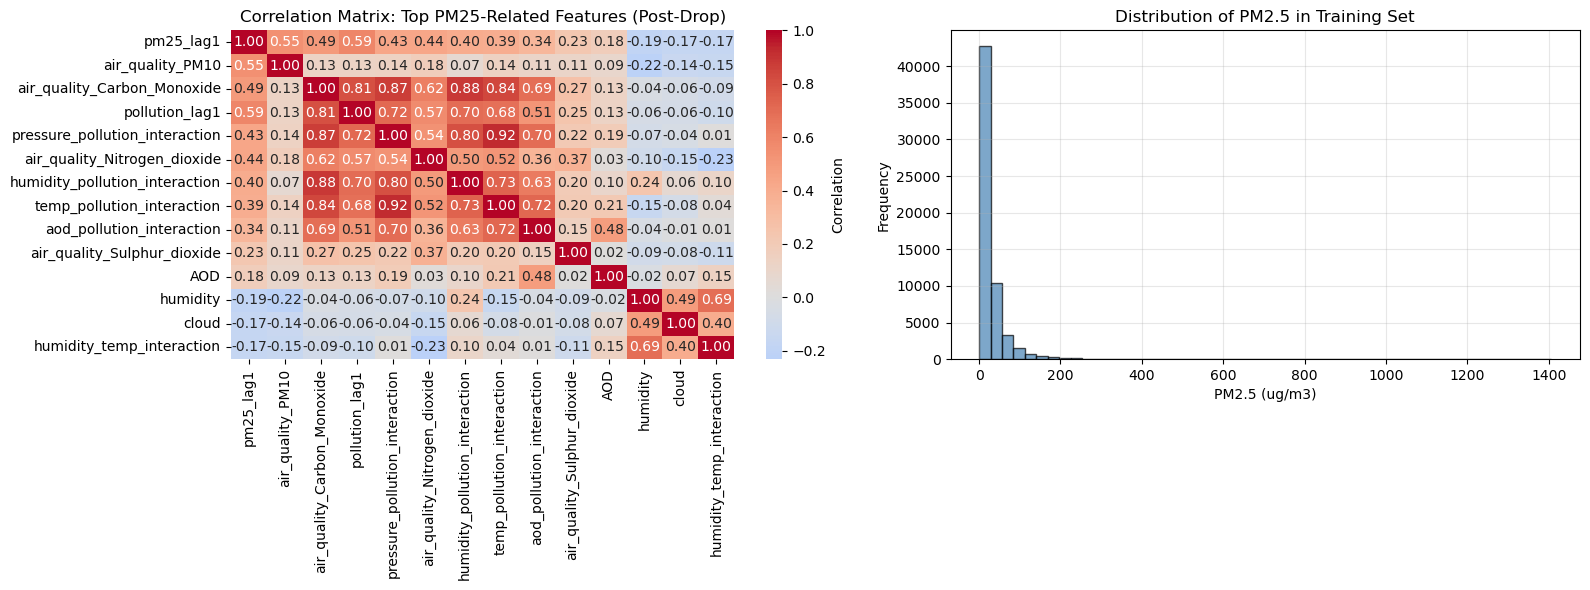

Target variable statistics:
count    59824.000000
mean        27.688835
std         41.297359
min          0.185000
25%          8.140000
50%         16.095000
75%         31.635000
max       1406.300000
Name: pm25, dtype: float64


In [98]:
# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations with target (exclude pm25 itself)
top_features = [f for f in target_corr.abs().nlargest(15).index.tolist() if f != 'pm25'][:15]
# Ensure selected features still exist after correlation-based dropping
top_features = [f for f in top_features if f in X_train.columns]
subset_corr = X_train[top_features].corr()

sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix: Top PM25-Related Features (Post-Drop)')

# Distribution of target variable
axes[1].hist(y_train, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].set_xlabel('PM2.5 (ug/m3)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of PM2.5 in Training Set')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Target variable statistics:")
print(y_train.describe())

## Decision: Drop Highly Correlated Features

Features with absolute pairwise correlation above the threshold are removed to reduce redundancy and improve model stability.

- Correlation threshold: **0.95**
- Selection rule: drop one feature from each highly correlated pair using the upper-triangle method
- Apply the same dropped-feature list to **train**, **validation**, and **test** feature matrices

---
# PHASE 7: Quality Assurance 

In [99]:
print("="*80)
print("FINAL QUALITY ASSURANCE & SUMMARY")
print("="*80)

print("\n1. DATA INTEGRITY CHECKS:")
print(f"   ✓ No NaN values in X_train: {X_train.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_val: {X_val.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_test: {X_test.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in y_train: {y_train.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_val: {y_val.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_test: {y_test.isnull().sum() == 0}")

FINAL QUALITY ASSURANCE & SUMMARY

1. DATA INTEGRITY CHECKS:
   ✓ No NaN values in X_train: True
   ✓ No NaN values in X_val: True
   ✓ No NaN values in X_test: True
   ✓ No NaN values in y_train: True
   ✓ No NaN values in y_val: True
   ✓ No NaN values in y_test: True


In [100]:
print("\n2. FEATURE DIMENSION CHECKS:")
print(f"   ✓ X_train features: {X_train.shape[1]}")
print(f"   ✓ X_val features: {X_val.shape[1]}")
print(f"   ✓ X_test features: {X_test.shape[1]}")
print(f"   ✓ All have same feature count: {X_train.shape[1] == X_val.shape[1] == X_test.shape[1]}")

print("\n3. TEMPORAL ORDERING VERIFICATION:")
print(f"   ✓ Train dates: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"   ✓ Val dates:   {df_val['date'].min()} to {df_val['date'].max()}")
print(f"   ✓ Test dates:  {df_test['date'].min()} to {df_test['date'].max()}")
print(f"   ✓ No overlap between splits: {df_train['date'].max() < df_val['date'].min() and df_val['date'].max() < df_test['date'].min()}")


2. FEATURE DIMENSION CHECKS:
   ✓ X_train features: 38
   ✓ X_val features: 38
   ✓ X_test features: 38
   ✓ All have same feature count: True

3. TEMPORAL ORDERING VERIFICATION:
   ✓ Train dates: 2024-05-16 00:00:00 to 2025-09-28 00:00:00
   ✓ Val dates:   2025-09-29 00:00:00 to 2025-12-09 00:00:00
   ✓ Test dates:  2025-12-10 00:00:00 to 2026-05-01 00:00:00
   ✓ No overlap between splits: True


In [101]:
print("\n4. SCALING VERIFICATION:")
# Check that scaled features have expected properties
print(f"   ✓ StandardScaler features mean ≈ 0: {X_train[scaling_config['standard'][0]].mean():.4f}")
print(f"   ✓ StandardScaler features std ≈ 1: {X_train[scaling_config['standard'][0]].std():.4f}")
print(f"   ✓ RobustScaler applied to pollution features: {len(scaling_config['robust'])} features")
print(f"   ✓ Preserved geographic/categorical features: {len(scaling_config['no_scale'])} features")


4. SCALING VERIFICATION:
   ✓ StandardScaler features mean ≈ 0: 0.0000
   ✓ StandardScaler features std ≈ 1: 1.0000
   ✓ RobustScaler applied to pollution features: 28 features
   ✓ Preserved geographic/categorical features: 14 features


In [102]:
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

# Calculate actual feature count
actual_features = [f for f in all_scaling_features if f in X_train.columns]
total_temporal_eng = len([f for f in engineered_features if f in X_train.columns])

summary_stats = {
    'Metric': [
        'Total Features',
        'Temporal Features',
        'Engineered Features',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Target: Mean PM25',
        'Target: Std PM25',
        'Target: Min PM25',
        'Target: Max PM25',
        'Missing Values (original)',
        'Missing Values (final)',
        'Scaling: StandardScaler',
        'Scaling: RobustScaler',
        'Files Saved'
    ],
    'Value': [
        len([f for f in all_scaling_features if f in X_train.columns]),
        len([f for f in temporal_features if f in X_train.columns]),
        total_temporal_eng,
        len(X_train),
        len(X_val),
        len(X_test),
        f"{y_train.mean():.2f} μg/m³",
        f"{y_train.std():.2f} μg/m³",
        f"{y_train.min():.2f} μg/m³",
        f"{y_train.max():.2f} μg/m³",
        "Pollution, Lag features (varies)",
        "0",
        len(scaling_config['standard']),
        len(scaling_config['robust']),
        "7 files (train/val/test + X/y + scalers)"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("✓ PREPROCESSING PIPELINE COMPLETE")
print("="*80)
print("\nREADY FOR MODEL TRAINING!")
print("\nKey Files Generated in preprocessed_data/:")
print("  1. X_train.csv / y_train.csv - Training features and target")
print("  2. X_val.csv / y_val.csv - Validation features and target")
print("  3. X_test.csv / y_test.csv - Test features and target (HOLD OUT)")
print("  4. standard_scaler.pkl - Fitted scaler for inference")
print("  5. robust_scaler.pkl - Fitted scaler for inference")
print("  6. scaling_config.pkl - Feature grouping configuration")

print("\nNext Steps:")
print("  1. Load X_train, y_train with TimeSeriesSplit CV")
print("  2. Train multiple models (Random Forest, XGBoost, LightGBM, etc.)")
print("  3. Monitor train vs validation error for overfitting detection")
print("  4. Select best model based on validation performance")
print("  5. Evaluate ONLY on X_test, y_test (final assessment)")
print("  6. Save best model + scaling artifacts for production deployment")


PREPROCESSING SUMMARY

                   Metric                                    Value
           Total Features                                       38
        Temporal Features                                        8
      Engineered Features                                       17
         Training Samples                                    59824
       Validation Samples                                     8292
             Test Samples                                    15588
        Target: Mean PM25                              27.69 μg/m³
         Target: Std PM25                              41.30 μg/m³
         Target: Min PM25                               0.18 μg/m³
         Target: Max PM25                            1406.30 μg/m³
Missing Values (original)         Pollution, Lag features (varies)
   Missing Values (final)                                        0
  Scaling: StandardScaler                                        4
    Scaling: RobustScaler             